# Student Autoencoder V2

Version 2 keeps the **same student-only model** and changes only the **training / scoring strategy**:

- lower feature distillation weight
- mixed pixel loss: masked mean L1 + masked top-k L1
- anomaly score: masked `topk_mean` on the residual map
- threshold: validation quantile only

The stable spatial mask is enabled by default because the upper border / edge zones are visibly less stable. Set `USE_STABLE_SPATIAL_MASK = False` in the config cell if you want to disable it.


## Dataset

This notebook expects a prepared anomaly dataset with `train / validation / test` CSV files. It uses the validation split only for threshold calibration, without ROC-based tuning.


In [1]:
import json
import os
import sys
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import torch
from torch.utils.data import DataLoader

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

os.chdir(PROJECT_ROOT)
print(f"Project root: {PROJECT_ROOT}")


Project root: C:\Users\memel\Studcamp\smart-trash-ml


In [2]:
from configs.student_autoencoder_esp import TrainConfig
from src.data.student_autoencoder_dataset import StudentAutoencoderDataset
from src.testers.student_autoencoder_evaluator import StudentAutoencoderEvaluator
from src.trainers.student_autoencoder_trainer import StudentAutoencoderTrainer


C:\Users\memel\Studcamp\smart-trash-ml\.venv\Lib\site-packages\torch\cuda\__init__.py:180: UserWarning: cudaGetDeviceCount() returned cudaErrorNotSupported, likely using older driver or on CPU machine (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\c10\cuda\CUDAFunctions.cpp:88.)
  return torch._C._cuda_getDeviceCount() > 0


In [3]:
def build_loader(dataset, batch_size, shuffle, num_workers):
    return DataLoader(dataset, batch_size=batch_size, shuffle=shuffle, num_workers=num_workers)


def count_parameters(module: torch.nn.Module) -> tuple[int, int]:
    total = sum(parameter.numel() for parameter in module.parameters())
    trainable = sum(parameter.numel() for parameter in module.parameters() if parameter.requires_grad)
    return total, trainable


def show_samples(dataset, title: str, max_samples: int = 4) -> None:
    count = min(len(dataset), max_samples)
    figure, axes = plt.subplots(1, count, figsize=(4 * count, 4))
    if count == 1:
        axes = [axes]

    for index in range(count):
        sample = dataset[index]
        image = sample["reconstruction_target"].squeeze(0).numpy()
        axes[index].imshow(image, cmap="gray", vmin=0.0, vmax=1.0)
        axes[index].set_title(f"label={sample['label']}")
        axes[index].axis("off")

    figure.suptitle(title)
    plt.tight_layout()
    plt.show()


def op_summary(model: torch.nn.Module) -> Counter:
    return Counter(type(module).__name__ for module in model.modules())


In [4]:
EXP_NAME = "student_autoencoder_esp_v2_masked_topk"
DATASET_ROOT = PROJECT_ROOT / "data" / "anomaly" / "anomaly_detection_dataset_v3"
USE_STABLE_SPATIAL_MASK = True

if not (DATASET_ROOT / "labels" / "train.csv").exists():
    raise FileNotFoundError(
        f"Prepared dataset is missing: {DATASET_ROOT}",
    )

cfg = TrainConfig(
    train_csv=str(DATASET_ROOT / "labels" / "train.csv"),
    valid_csv=str(DATASET_ROOT / "labels" / "validation.csv"),
    test_csv=str(DATASET_ROOT / "labels" / "test.csv"),
    img_dir=str(DATASET_ROOT),
    epochs=80,
    batch_size=32,
    distillation_weight=0.05,
    pixel_topk_ratio=0.02,
    pixel_topk_weight=0.35,
    score_mode="topk_mean",
    score_topk_ratio=0.02,
    use_stable_spatial_mask=USE_STABLE_SPATIAL_MASK,
    stable_mask_top_fraction=0.14,
    stable_mask_bottom_fraction=0.03,
    stable_mask_left_fraction=0.04,
    stable_mask_right_fraction=0.04,
)

base_dir = PROJECT_ROOT / "experiments" / "anomaly_detection" / EXP_NAME
weights_dir = base_dir / "weights"
artifacts_dir = base_dir / "artifacts"
weights_dir.mkdir(parents=True, exist_ok=True)
artifacts_dir.mkdir(parents=True, exist_ok=True)

cfg.save_to_json(str(base_dir / "config.json"))
print(cfg)


TrainConfig(train_csv='C:\\Users\\memel\\Studcamp\\smart-trash-ml\\data\\anomaly\\anomaly_detection_dataset_v3\\labels\\train.csv', valid_csv='C:\\Users\\memel\\Studcamp\\smart-trash-ml\\data\\anomaly\\anomaly_detection_dataset_v3\\labels\\validation.csv', test_csv='C:\\Users\\memel\\Studcamp\\smart-trash-ml\\data\\anomaly\\anomaly_detection_dataset_v3\\labels\\test.csv', img_dir='C:\\Users\\memel\\Studcamp\\smart-trash-ml\\data\\anomaly\\anomaly_detection_dataset_v3', input_size=96, input_channels=1, roi=ROIConfig(x=0, y=0, w=128, h=128), epochs=80, batch_size=32, learning_rate=0.0008, weight_decay=1e-05, num_workers=0, device='cpu', encoder_channels=(16, 24, 32, 48), bottleneck_channels=64, pixel_loss_weight=1.0, distillation_weight=0.05, feature_distillation_weights=(1.0, 0.75, 0.5), teacher_encoder_name='mobilenet_v3_small', use_pretrained_teacher=True, use_teacher_distillation=True, pixel_topk_ratio=0.02, pixel_topk_weight=0.35, score_mode='topk_mean', score_topk_ratio=0.02, thres

train normal samples: 2048
validation normal samples: 896
test mixed samples: 906


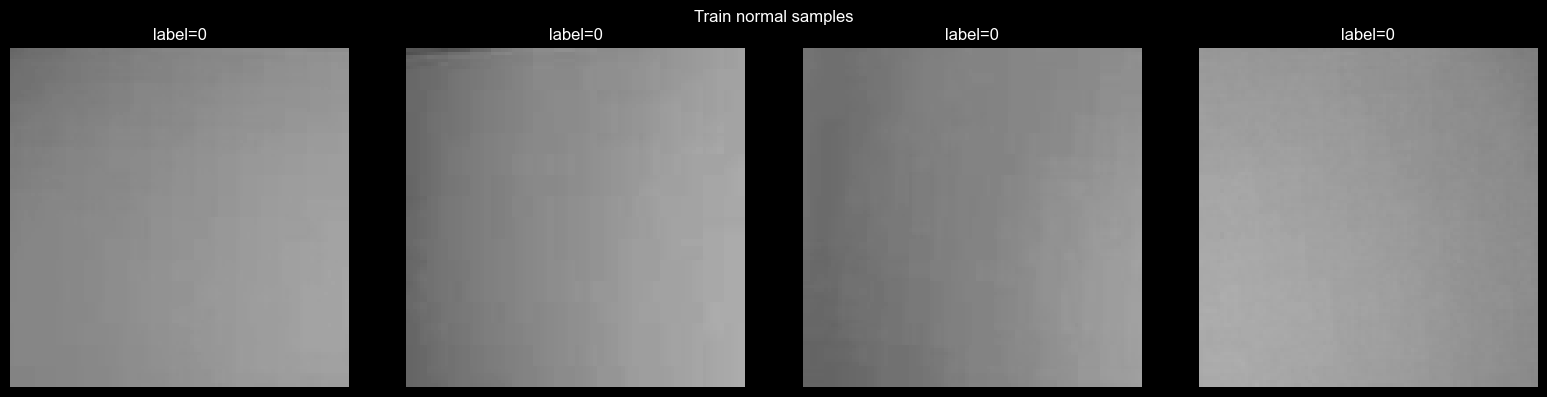

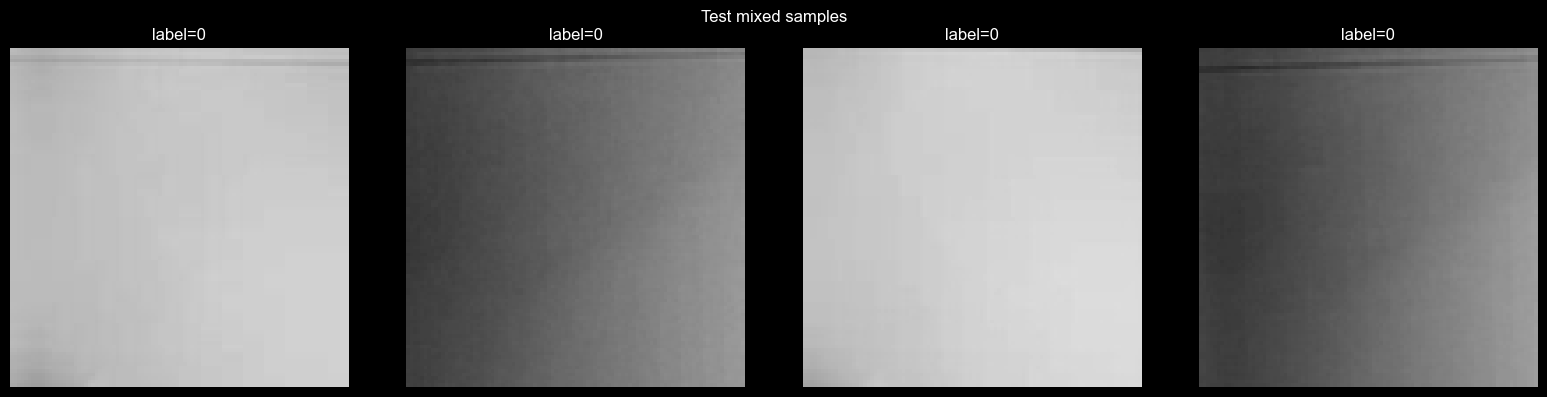

In [5]:
train_dataset = StudentAutoencoderDataset(
    csv_file=cfg.train_csv,
    root_dir=cfg.img_dir,
    image_size=cfg.input_size,
    roi=cfg.roi,
    normal_only=True,
    augment_horizontal_flip=cfg.train_horizontal_flip,
)
val_dataset = StudentAutoencoderDataset(
    csv_file=cfg.valid_csv,
    root_dir=cfg.img_dir,
    image_size=cfg.input_size,
    roi=cfg.roi,
    normal_only=True,
    augment_horizontal_flip=False,
)
test_dataset = StudentAutoencoderDataset(
    csv_file=cfg.test_csv,
    root_dir=cfg.img_dir,
    image_size=cfg.input_size,
    roi=cfg.roi,
    normal_only=False,
    augment_horizontal_flip=False,
)

train_loader = build_loader(train_dataset, cfg.batch_size, True, cfg.num_workers)
val_loader = build_loader(val_dataset, cfg.batch_size, False, cfg.num_workers)
test_loader = build_loader(test_dataset, cfg.batch_size, False, cfg.num_workers)

print(f"train normal samples: {len(train_dataset)}")
print(f"validation normal samples: {len(val_dataset)}")
print(f"test mixed samples: {len(test_dataset)}")
show_samples(train_dataset, "Train normal samples")
show_samples(test_dataset, "Test mixed samples")


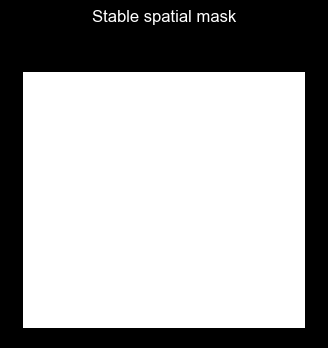

In [6]:
mask = cfg.get_spatial_mask(
    height=cfg.input_size,
    width=cfg.input_size,
    device="cpu",
    dtype=torch.float32,
)

if mask is None:
    print("stable spatial mask: disabled")
else:
    plt.figure(figsize=(4, 4))
    plt.imshow(mask.squeeze(0).squeeze(0).numpy(), cmap="gray", vmin=0.0, vmax=1.0)
    plt.title("Stable spatial mask")
    plt.axis("off")
    plt.show()


In [6]:
def build_model():
    return cfg.get_model()


model = build_model()
teacher = cfg.get_teacher()

student_total, student_trainable = count_parameters(model)
print(f"student params: total={student_total:,}, trainable={student_trainable:,}")
print(f"student int8 weights: ~{student_total / 1024:.1f} KB")
print("student ops:")
for name, count in sorted(op_summary(model).items()):
    print(f"  {name}: {count}")

if teacher is None:
    print("teacher: disabled")
else:
    teacher_total, _ = count_parameters(teacher)
    print(f"teacher params (training only): total={teacher_total:,}")


student params: total=143,521, trainable=143,521
student int8 weights: ~140.2 KB
student ops:
  Conv2d: 12
  ConvReLU: 11
  ReLU: 11
  Sequential: 2
  Sigmoid: 1
  StudentOnlyAutoencoder: 1
  UpsampleConvBlock: 4
teacher params (training only): total=927,008


In [ ]:
trainer = StudentAutoencoderTrainer(config=cfg, save_dir=str(weights_dir))
history = trainer.fit(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    teacher=teacher,
)

plt.figure(figsize=(11, 5))
plt.plot(history["train_loss"], label="train_total_loss", marker="o")
plt.plot(history["val_loss"], label="val_total_loss", marker="o")
plt.plot(history["train_pixel_loss"], label="train_pixel_loss", linestyle="--")
plt.plot(history["val_pixel_loss"], label="val_pixel_loss", linestyle="--")
plt.plot(history["train_pixel_topk_loss"], label="train_pixel_topk_loss", linestyle=":")
plt.plot(history["val_pixel_topk_loss"], label="val_pixel_topk_loss", linestyle=":")
plt.plot(history["train_distillation_loss"], label="train_distillation_loss", linestyle="-.")
plt.plot(history["val_distillation_loss"], label="val_distillation_loss", linestyle="-.")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training history")
plt.legend()
plt.grid(True)
plt.show()



--- Epoch 1/80 ---


*** Saved new best student autoencoder (val_loss=0.0906) ***
Train Loss: 0.1017 | Pixel: 0.0636 | TopK Pixel: 0.1381 | Distill: 0.2403
Validation Loss: 0.0906 | Pixel: 0.0518 | TopK Pixel: 0.1280 | Distill: 0.2424

--- Epoch 2/80 ---


*** Saved new best student autoencoder (val_loss=0.0242) ***
Train Loss: 0.0462 | Pixel: 0.0206 | TopK Pixel: 0.0607 | Distill: 0.2329
Validation Loss: 0.0242 | Pixel: 0.0071 | TopK Pixel: 0.0244 | Distill: 0.2207

--- Epoch 3/80 ---


*** Saved new best student autoencoder (val_loss=0.0223) ***
Train Loss: 0.0236 | Pixel: 0.0075 | TopK Pixel: 0.0259 | Distill: 0.1923
Validation Loss: 0.0223 | Pixel: 0.0084 | TopK Pixel: 0.0218 | Distill: 0.1841

--- Epoch 4/80 ---


*** Saved new best student autoencoder (val_loss=0.0186) ***
Train Loss: 0.0242 | Pixel: 0.0100 | TopK Pixel: 0.0271 | Distill: 0.1640
Validation Loss: 0.0186 | Pixel: 0.0061 | TopK Pixel: 0.0184 | Distill: 0.1654

--- Epoch 5/80 ---


...

Train Loss: 0.0119 | Pixel: 0.0045 | TopK Pixel: 0.0162 | Distill: 0.0669
Validation Loss: 0.0107 | Pixel: 0.0044 | TopK Pixel: 0.0140 | Distill: 0.0588

--- Epoch 73/80 ---


*** Saved new best student autoencoder (val_loss=0.0093) ***
Train Loss: 0.0116 | Pixel: 0.0043 | TopK Pixel: 0.0157 | Distill: 0.0664
Validation Loss: 0.0093 | Pixel: 0.0034 | TopK Pixel: 0.0118 | Distill: 0.0597

--- Epoch 74/80 ---


Train Loss: 0.0118 | Pixel: 0.0045 | TopK Pixel: 0.0161 | Distill: 0.0659
Validation Loss: 0.0104 | Pixel: 0.0042 | TopK Pixel: 0.0136 | Distill: 0.0593

--- Epoch 75/80 ---


Train Loss: 0.0117 | Pixel: 0.0044 | TopK Pixel: 0.0159 | Distill: 0.0659
Validation Loss: 0.0116 | Pixel: 0.0051 | TopK Pixel: 0.0149 | Distill: 0.0609

--- Epoch 76/80 ---


Train:  23%|██▎       | 15/64 [00:17<00:49,  1.01s/it, loss=0.0116]

In [7]:
best_weights_path = weights_dir / "best_model.pth"
model = build_model()
model.load_state_dict(torch.load(best_weights_path, map_location=cfg.device))
teacher = cfg.get_teacher()

evaluator = StudentAutoencoderEvaluator(
    config=cfg,
    device=cfg.device,
    save_dir=str(artifacts_dir / "test_residual_maps"),
)

val_predictions = evaluator.predict(model=model, dataloader=val_loader, teacher=teacher, save_anomaly_maps=False)
threshold = evaluator.compute_threshold(val_predictions["scores"])

test_predictions = evaluator.predict(
    model=model,
    dataloader=test_loader,
    teacher=teacher,
    save_anomaly_maps=cfg.save_anomaly_maps,
)
metrics = evaluator.compute_metrics(
    labels=test_predictions["labels"],
    scores=test_predictions["scores"],
    threshold=threshold,
)
metrics["avg_loss"] = test_predictions["avg_loss"]
metrics["num_samples"] = int(len(test_predictions["scores"]))

threshold_payload = {
    "threshold_mode": cfg.threshold_mode,
    "threshold_quantile": cfg.threshold_quantile,
    "threshold": threshold,
    "val_avg_loss": val_predictions["avg_loss"],
    "val_num_samples": int(len(val_predictions["scores"])),
    "score_mode": cfg.score_mode,
    "score_topk_ratio": cfg.score_topk_ratio,
    "pixel_topk_ratio": cfg.pixel_topk_ratio,
    "pixel_topk_weight": cfg.pixel_topk_weight,
    "use_stable_spatial_mask": cfg.use_stable_spatial_mask,
}

with open(artifacts_dir / "threshold.json", "w", encoding="utf-8") as file:
    json.dump(threshold_payload, file, indent=4)

with open(artifacts_dir / "test_metrics.json", "w", encoding="utf-8") as file:
    json.dump(metrics, file, indent=4)

evaluator.save_histogram(
    scores=test_predictions["scores"],
    labels=test_predictions["labels"],
    output_path=str(artifacts_dir / "test_score_histogram.png"),
)

print(json.dumps(metrics, indent=2))
print(json.dumps(threshold_payload, indent=2))
print(f"saved student weights: {best_weights_path}")


{
  "threshold": 0.016176216304302216,
  "precision_at_threshold": 0.5988700564971752,
  "recall_at_threshold": 0.7098214285714286,
  "f1_at_threshold": 0.6496424923391215,
  "roc_auc": 0.7127992436057392,
  "pr_auc": 0.7682511855677949,
  "avg_loss": 0.028476710022153708,
  "num_samples": 906
}
{
  "threshold_mode": "val_quantile",
  "threshold_quantile": 0.995,
  "threshold": 0.016176216304302216,
  "val_avg_loss": 0.009321110788732767,
  "val_num_samples": 896,
  "score_mode": "topk_mean",
  "score_topk_ratio": 0.02,
  "pixel_topk_ratio": 0.02,
  "pixel_topk_weight": 0.35,
  "use_stable_spatial_mask": true
}
saved student weights: C:\Users\memel\Studcamp\smart-trash-ml\experiments\anomaly_detection\student_autoencoder_esp_v2_masked_topk\weights\best_model.pth


## ESP Notes

Deployment graph is still the original student-only autoencoder:

- `Conv`
- `ReLU`
- `Resize(nearest)`
- `Sigmoid`

The masking / top-k logic is used only for training and evaluation, and the threshold is still calibrated only from the validation split.
